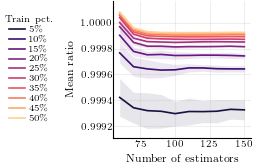

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter


# =============================================================================
# Matplotlib style: EXACTLY match ablation figures
# =============================================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


# =============================================================================
# Global parameters
# =============================================================================

RESULTS_CSV = Path(
    "/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260416_182227_oob_count_ratio_grid/oob_count_ratio_grid_results.csv"
)

PLOT_DATASET = "sign_mnist"
VALUE_COL = "fk_oob_ratio_mean"
PLOT_SEED = None

TRAIN_FRACS_TO_PLOT = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
CMAP_NAME = "magma"


# =============================================================================
# Geometry: SAME TOTAL WIDTH as ablation figures, and SAME PANEL SIZE as one subplot
# =============================================================================

COLUMN_WIDTH_PT = 241.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = COLUMN_WIDTH_PT * PT_TO_IN   # exact same total width as ablation figure

# Same individual subplot size as in ablation two-panel figures
ABL_LEFT = 0.10
ABL_RIGHT = 0.98
ABL_WSPACE = 0.14
ABL_NCOLS = 2

AXES_SIZE = FIG_WIDTH * (ABL_RIGHT - ABL_LEFT) / (
    ABL_NCOLS + (ABL_NCOLS - 1) * ABL_WSPACE
)

# Keep total figure width fixed, fit legend + square plot inside it
LEFT_LEGEND_WIDTH = FIG_WIDTH - AXES_SIZE - 0.10
RIGHT_MARGIN = 0.04
BOTTOM_MARGIN = 0.34
TOP_MARGIN = 0.05
FIG_HEIGHT = AXES_SIZE + BOTTOM_MARGIN + TOP_MARGIN


# =============================================================================
# Load and check data
# =============================================================================

if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"Could not find results CSV: {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV)

required_cols = {
    "dataset",
    "train_fraction",
    "n_estimators",
    VALUE_COL,
}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

df_plot = df[df["dataset"] == PLOT_DATASET].copy()

if PLOT_SEED is not None:
    if "seed" not in df_plot.columns:
        raise ValueError("PLOT_SEED was set, but column 'seed' is missing.")
    df_plot = df_plot[df_plot["seed"] == PLOT_SEED].copy()

if len(df_plot) == 0:
    raise ValueError(
        "No rows found for the requested selection:\n"
        f"  dataset={PLOT_DATASET}\n"
        f"  seed={PLOT_SEED}"
    )


# =============================================================================
# Aggregate over seeds
# =============================================================================

plot_df = (
    df_plot.groupby(["n_estimators", "train_fraction"], as_index=False)[VALUE_COL]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["train_fraction", "n_estimators"])
    .reset_index(drop=True)
)

plot_df["std"] = plot_df["std"].fillna(0.0)

all_train_fracs = sorted(plot_df["train_fraction"].unique())
TRAIN_FRACS_TO_PLOT = [x for x in TRAIN_FRACS_TO_PLOT if x in all_train_fracs]

if len(TRAIN_FRACS_TO_PLOT) == 0:
    raise ValueError("None of TRAIN_FRACS_TO_PLOT are present in the data.")


# =============================================================================
# Color helper
# =============================================================================

cmap = plt.get_cmap(CMAP_NAME)
frac_min = min(TRAIN_FRACS_TO_PLOT)
frac_max = max(TRAIN_FRACS_TO_PLOT)

def frac_to_color(frac: float):
    if frac_max == frac_min:
        return cmap(0.75)
    u = (frac - frac_min) / (frac_max - frac_min)
    return cmap(0.12 + 0.78 * u)


# =============================================================================
# Plot
# =============================================================================

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

# Place the square plot explicitly
ax_left = LEFT_LEGEND_WIDTH / FIG_WIDTH
ax_bottom = BOTTOM_MARGIN / FIG_HEIGHT
ax_width = AXES_SIZE / FIG_WIDTH
ax_height = AXES_SIZE / FIG_HEIGHT

ax = fig.add_axes([ax_left, ax_bottom, ax_width, ax_height])

for train_frac in TRAIN_FRACS_TO_PLOT:
    d = plot_df[np.isclose(plot_df["train_fraction"], train_frac)].copy().sort_values("n_estimators")

    x = d["n_estimators"].to_numpy()
    y = d["mean"].to_numpy()
    s = d["std"].to_numpy()

    color = frac_to_color(train_frac)

    ax.plot(
        x,
        y,
        color=color,
        label=rf"{100*train_frac:.0f}\%",
    )

    ax.fill_between(
        x,
        y - s,
        y + s,
        color=color,
        alpha=0.10,
        linewidth=0,
    )

ax.set_xlabel("Number of estimators")
ax.set_ylabel("Mean ratio")

ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))

ax.grid(True, alpha=0.20)

# Remove tick marks, keep numbers
ax.tick_params(axis="both", which="both", length=0, pad=1.5, labelsize=7)

# Only one spine per axis direction
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Small y-margin
ymin = (plot_df["mean"] - plot_df["std"]).min()
ymax = (plot_df["mean"] + plot_df["std"]).max()
yr = ymax - ymin
ax.set_ylim(ymin - 0.08 * yr, ymax + 0.08 * yr)

legend = ax.legend(
    frameon=False,
    ncol=1,
    title="Train pct.",
    title_fontsize=6.5,
    fontsize=6.5,
    loc="center left",
    bbox_to_anchor=(-0.82, 0.5),
    borderaxespad=0.0,
    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=0.8,
    labelspacing=0.20,
)

plt.show()

OUT_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/notebooks/compiled_oob_figure")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_base = OUT_DIR / "oob_ratio_vs_n_estimators_match_ablation_totalwidth"

fig.savefig(out_base.with_suffix(".pdf"))
# fig.savefig(out_base.with_suffix(".png"), dpi=400)

